# Read in the overdose data and adjacency file

In [37]:
import numpy as np
import pandas as pd

import sys
from pathlib import Path

project_root = Path.cwd().resolve()
if not (project_root / "data").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

from polygonal_surface import PolygonalSurface as PS

DATA_DIR = project_root / "data"
ADJ_PATH = DATA_DIR / "ohio_neighbors.txt"
COUNT_DATA_PATH = DATA_DIR / "county_drug_death.csv"
POP_NORMALIZED_DATA_PATH = DATA_DIR / "pop_normalized_county_drug_death.csv"

# choose how many vines we want to plot 
VINE_START_K = 0
VINE_END_K = 5
# this should stay 1 
DEGREE = 1


def load_vineyard_data(csv_path, smoothing=False, cumulative=False):
    df = pd.read_csv(csv_path).rename(columns={"Unnamed: 0": "county"})
    df = df.loc[~df["county"].astype(str).str.fullmatch("Total", case=False, na=False)].copy()

    # Set counties to be row names and use integer time steps for the vineyard code.
    df = df.set_index("county")
    df.columns = np.arange(df.shape[1])

    if smoothing:
        # Yearly rolling average.
        df = df.T.rolling(12, min_periods=1).mean().T
    if cumulative:
        df = df.cumsum(axis=1)

    vineyard_data = {county: df.loc[county].tolist() for county in df.index}
    return df, vineyard_data

# Raw Death Count, Smoothed

In [42]:
%%capture
df, vineyard_data = load_vineyard_data(
    COUNT_DATA_PATH,
    smoothing=True,
    cumulative=False,
)
ps = PS.read_adj(ADJ_PATH)

Exterior filtration: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.08333333333333333, 0.08333333333333333, 0.08333333333333333, 0.08333333333333333, 0.08333333333333333, 0.08333333333333333, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.08333333333333333, 0.08333333333333333, 0.08333333333333333, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.08333333333333333, 0.08333333333333333, 0.08333333333333333, 0.08333333333333333, 0.08333333333333333, 0.08333333333333333, 0.08333333333333333, 0.08333333333333333, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.08333333333333333, 0.0, 0.0, 0.0, 0.0, 0.08333333333333333, 0.08333333333333333

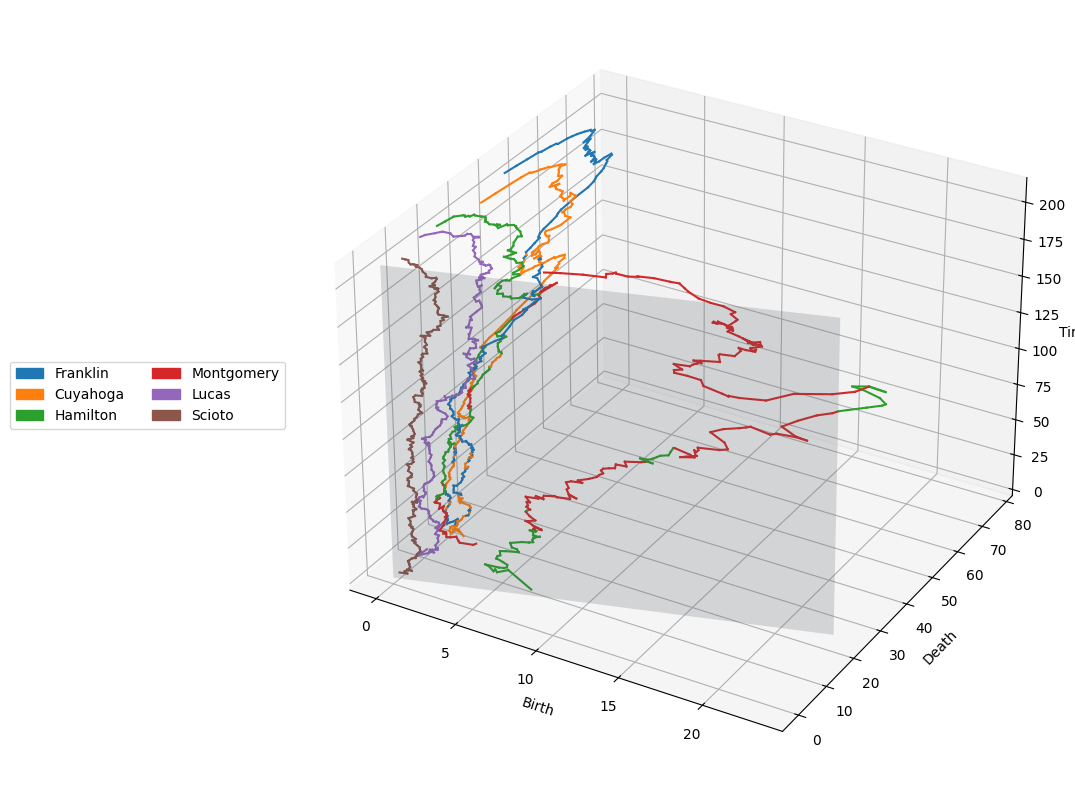

{'Franklin': array([0.12156863, 0.46666667, 0.70588235, 1.        ]),
 'Cuyahoga': array([1.        , 0.49803922, 0.05490196, 1.        ]),
 'Hamilton': array([0.17254902, 0.62745098, 0.17254902, 1.        ]),
 'Montgomery': array([0.83921569, 0.15294118, 0.15686275, 1.        ]),
 'Lucas': array([0.58039216, 0.40392157, 0.74117647, 1.        ]),
 'Scioto': array([0.54901961, 0.3372549 , 0.29411765, 1.        ])}

In [43]:
vy = ps.toVineyard(vineyard_data, dim=DEGREE)
vy.plot(VINE_START_K, VINE_END_K, label_by_region=True, include_represented_vines=True)

# Raw Death Count, Cumulative

In [44]:
%%capture
df, vineyard_data = load_vineyard_data(
    COUNT_DATA_PATH,
    smoothing=False,
    cumulative=True,
)
ps = PS.read_adj(ADJ_PATH)

Exterior filtration: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 10, 10, 11, 11, 11, 11, 13, 13, 13, 14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 15, 15, 15, 15, 16, 16, 17, 17, 17, 18, 18, 19, 19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20, 20, 20, 20, 20, 20, 21, 21, 22, 23, 23, 23, 23, 23, 23, 23, 24, 24, 24, 25, 25, 25, 25, 26, 27, 27, 27, 27, 27, 27, 27, 28, 28, 28, 28, 28, 28, 28, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 29, 30, 30, 30, 30, 30, 30, 30]


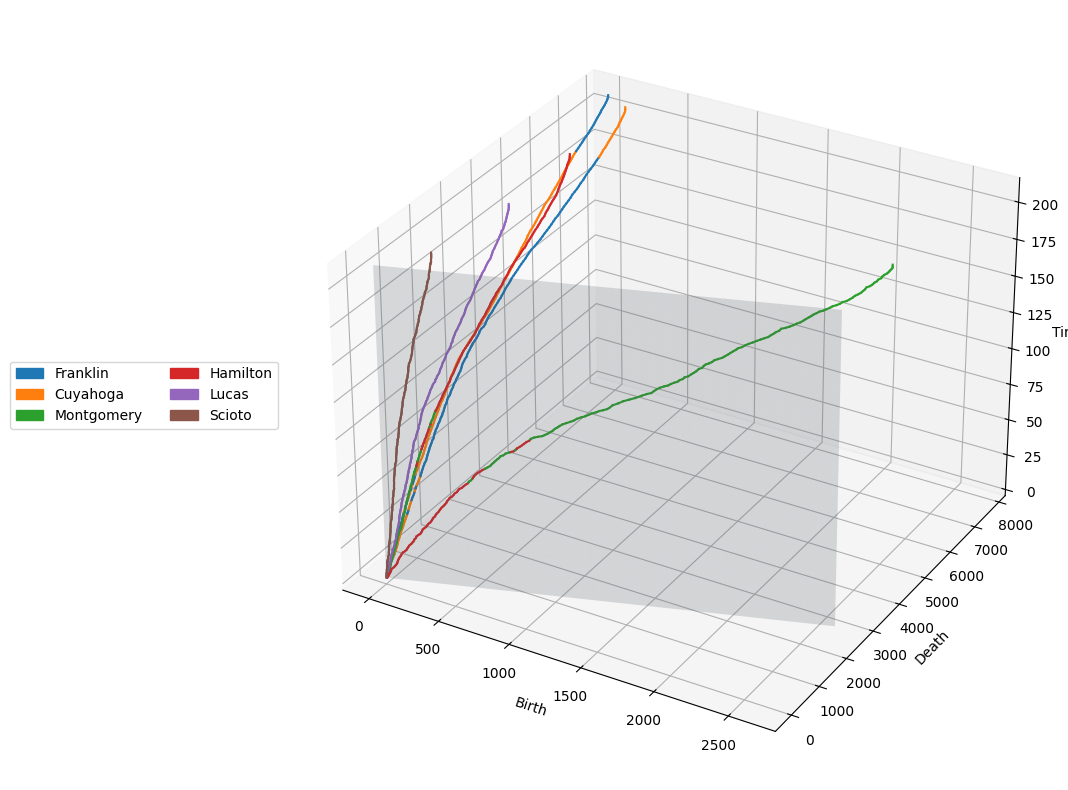

{'Franklin': array([0.12156863, 0.46666667, 0.70588235, 1.        ]),
 'Cuyahoga': array([1.        , 0.49803922, 0.05490196, 1.        ]),
 'Montgomery': array([0.17254902, 0.62745098, 0.17254902, 1.        ]),
 'Hamilton': array([0.83921569, 0.15294118, 0.15686275, 1.        ]),
 'Lucas': array([0.58039216, 0.40392157, 0.74117647, 1.        ]),
 'Scioto': array([0.54901961, 0.3372549 , 0.29411765, 1.        ])}

In [45]:
vy = ps.toVineyard(vineyard_data, dim=DEGREE)
vy.plot(VINE_START_K, VINE_END_K, label_by_region=True, include_represented_vines=True)

# Population Normalized, Smoothed

In [51]:
%%capture
df, vineyard_data = load_vineyard_data(
    POP_NORMALIZED_DATA_PATH,
    smoothing=True,
    cumulative=False,
)
ps = PS.read_adj(ADJ_PATH)

## Do not show lower-persistence representative vines here since its far too messy 

Exterior filtration: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.0413829144415592e-06, 3.6400539419703535e-06, 2.9364352312330344e-06, 1.4718003061344649e-06, 1.4718003061344649e-06, 2.9563407596613215e-06, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.1566876241165714e-06, 2.645922633222205e-06, 3.699264586200263e-06, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.7549377431322185e-06, 3.7549377431322185e-06, 3.0168096634447152e-06, 3.029972487849813e-06, 3.029972487849813e-06, 4.37951089622311e-06, 4.37951089622311e-06, 4.37951089622311e-06, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 4.404743027291788e-06, 0.0, 0.0, 0.0, 0.

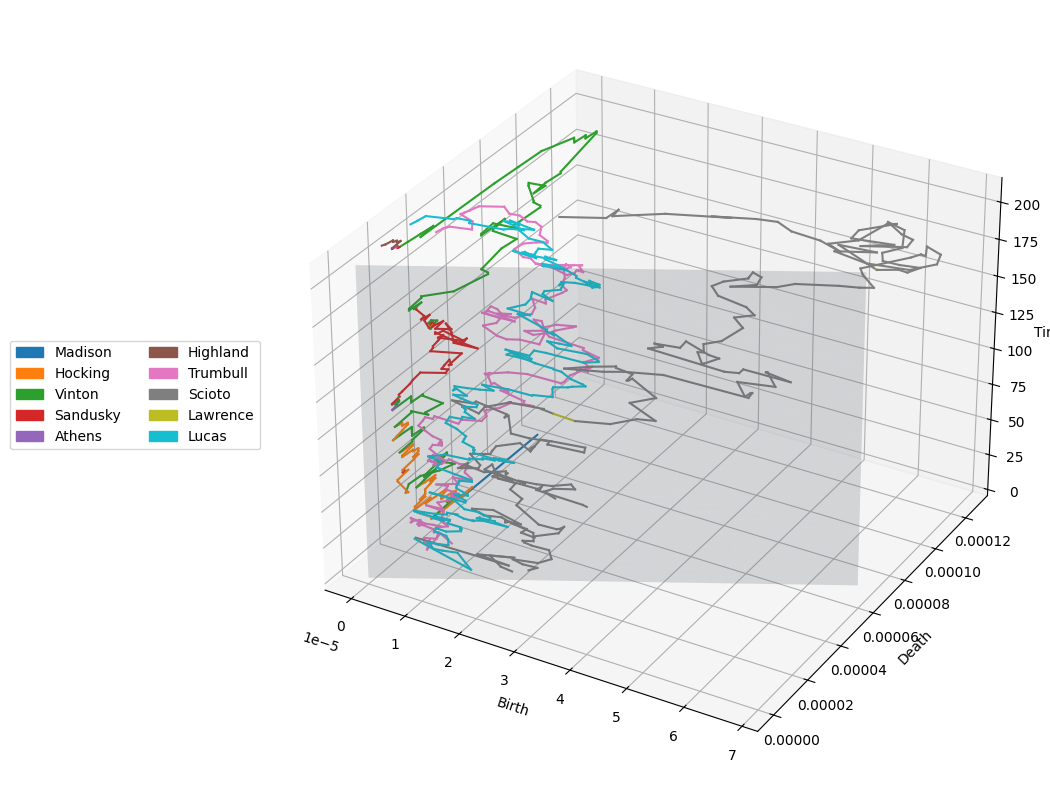

{'Madison': array([0.12156863, 0.46666667, 0.70588235, 1.        ]),
 'Hocking': array([1.        , 0.49803922, 0.05490196, 1.        ]),
 'Vinton': array([0.17254902, 0.62745098, 0.17254902, 1.        ]),
 'Sandusky': array([0.83921569, 0.15294118, 0.15686275, 1.        ]),
 'Athens': array([0.58039216, 0.40392157, 0.74117647, 1.        ]),
 'Highland': array([0.54901961, 0.3372549 , 0.29411765, 1.        ]),
 'Trumbull': array([0.89019608, 0.46666667, 0.76078431, 1.        ]),
 'Scioto': array([0.49803922, 0.49803922, 0.49803922, 1.        ]),
 'Lawrence': array([0.7372549 , 0.74117647, 0.13333333, 1.        ]),
 'Lucas': array([0.09019608, 0.74509804, 0.81176471, 1.        ])}

In [54]:
vy = ps.toVineyard(vineyard_data, dim=DEGREE)
vy.plot(VINE_START_K, 3, label_by_region=True)

# Population Normalized, Cumulative

In [48]:
%%capture
df, vineyard_data = load_vineyard_data(
    POP_NORMALIZED_DATA_PATH,
    smoothing=False,
    cumulative=True,
)
ps = PS.read_adj(ADJ_PATH)

Exterior filtration: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 6.78334011667345e-05, 6.78334011667345e-05, 6.78334011667345e-05, 6.78334011667345e-05, 6.78334011667345e-05, 7.172572084349448e-05, 7.172572084349448e-05, 7.172572084349448e-05, 7.172572084349448e-05, 7.172572084349448e-05, 7.172572084349448e-05, 7.172572084349448e-05, 0.00011881113378256596, 0.00011881113378256596, 0.00011881113378256596, 0.00011881113378256596, 0.00011881113378256596, 0.00011881113378256596, 0.00011881113378256596, 0.00011881113378256596, 0.00011881113378256596, 0.00011881113378256596, 0.00011881113378256596, 0.00011881113378256596, 0.00011881113378256596, 0.00011881113378256596, 0.00011881113378256596, 0.00014216361615144177, 0.00014216361615144177, 0.00014216361615144177, 0.00014216361615144177, 0.00014216361615144177, 0.00014216361615144177, 0.00014216361615144177, 0.00014216361615144177, 0.00014216361615144177, 0.0001

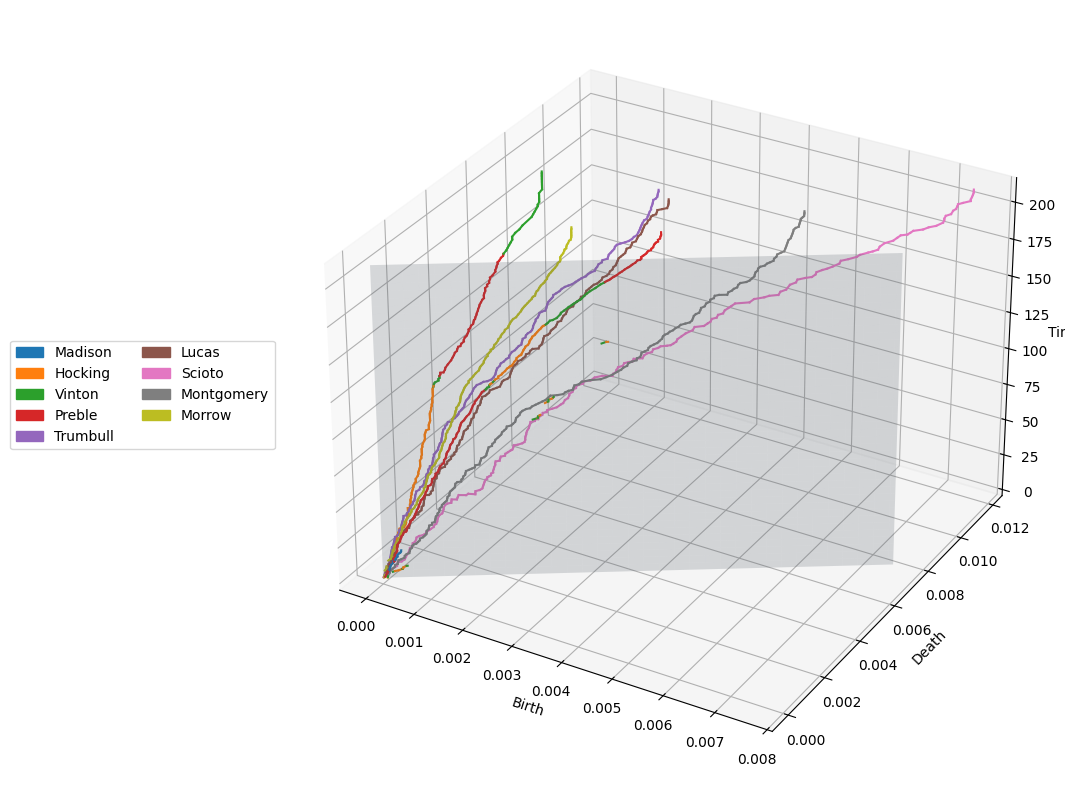

{'Madison': array([0.12156863, 0.46666667, 0.70588235, 1.        ]),
 'Hocking': array([1.        , 0.49803922, 0.05490196, 1.        ]),
 'Vinton': array([0.17254902, 0.62745098, 0.17254902, 1.        ]),
 'Preble': array([0.83921569, 0.15294118, 0.15686275, 1.        ]),
 'Trumbull': array([0.58039216, 0.40392157, 0.74117647, 1.        ]),
 'Lucas': array([0.54901961, 0.3372549 , 0.29411765, 1.        ]),
 'Scioto': array([0.89019608, 0.46666667, 0.76078431, 1.        ]),
 'Montgomery': array([0.49803922, 0.49803922, 0.49803922, 1.        ]),
 'Morrow': array([0.7372549 , 0.74117647, 0.13333333, 1.        ])}

In [49]:
vy = ps.toVineyard(vineyard_data, dim=DEGREE)
vy.plot(VINE_START_K, VINE_END_K, label_by_region=True, include_represented_vines=True)